# EI and Term Curves Across Scales

This notebook reads `EI_scale*.csv`, `term1_scale*.csv`, and `term2_scale*.csv` from `loc_result_stage2/stage2_macro`.
It provides:
- one EI figure across all available scales
- one EI tail-mean summary figure
- one helper to draw `term1` and `term2` for a single scale
- one helper to draw all scales together as a large subplot grid


In [1]:
from __future__ import annotations

import math
import re
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

In [2]:
def moving_average(data, window_size):   
    return np.convolve(data, np.ones(window_size)/window_size, mode='valid')  
def cal_data(ei_list):      
    y = ei_list   
    window_size = 1
    y_smooth = np.array([moving_average(y[:,i], window_size) for i in range(y.shape[1])]).T
    new_ei = np.mean(y_smooth[-1:],axis=0) 
    return y_smooth, new_ei    

FileNotFoundError: [Errno 2] No such file or directory: './loc_result_stage1/stage1_kuramoto_macro/term1_scale.csv'

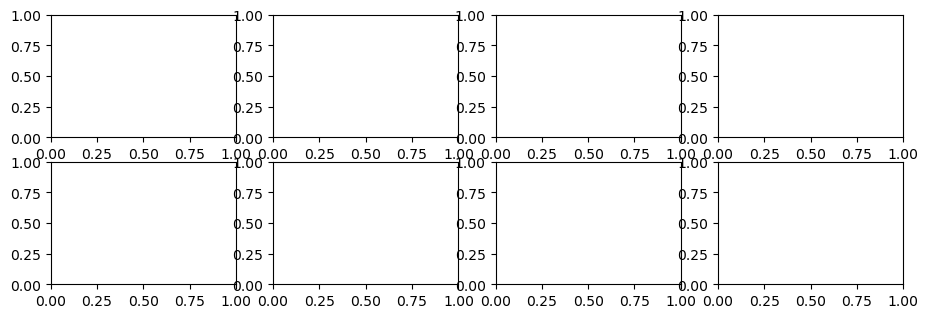

In [6]:
fig,ax1=plt.subplots(2,4, figsize= (11, 3.5))  
scale_number = [32, 16, 8, 4, 2, 1]
ei_all = []
all_ei_list = []
for type_name in ['des']: 
    for mice_name in [16]:  
        for stage_name in [0]:  
            ei_stage1, ei_stage2, ei_stage3 = [], [], []
            left, right = 0, 0 
            term1_list1 = pd.read_csv('./loc_result_stage1/stage1_kuramoto_macro/term1_scale.csv',header=None)
            term1_list2 = pd.read_csv('./loc_result_stage1/stage1_kuramoto_macro/term2_scale.csv',header=None)
            term_all = np.array(term1_list1) + np.array(term1_list2)
            for weights in range(6): 
                smooth_data, ei = cal_data(term_all[:,weights:(weights+1)])
                all_ei_list.append(smooth_data)
                # ax1[left][right].plot(np.arange(term_all.shape[0])*1000, term_all, label=r'$\mathcal{J}$')
                ei_all.append(ei[0])
                ax1[left][right].plot(np.arange(smooth_data.shape[0])*200, smooth_data, label=r'$\mathcal{J}$=%s'%(round(np.mean(smooth_data[-5:,0]),3)))
                ax1[left][right].set_title('dim=%s'%(scale_number[weights]), fontsize=8)
                ax1[left][right].set_xlabel('epoch', fontsize=8)
                ax1[left][right].set_ylabel(r'$\mathcal{J}$', fontsize=8)
                # ax1[left][right].xaxis.set_major_formatter(ScalarFormatter(useMathText=True))
                ax1[left][right].ticklabel_format(axis='x', style='sci', scilimits=(0,0))
                # ax1[left][right].xaxis.set_ticks(x + bar_width, freq_list)
                ax1[left][right].tick_params(labelsize=8)    
                # if left ==0 and right ==0:
                # ax1[left][right].set_ylim(0,4)     
                ax1[left][right].legend(fontsize=5)    
                right += 1    
                if right %4 == 0:    
                    left += 1   
                    right = 0   
                plt.subplots_adjust(wspace=0.4, hspace=0.9) 

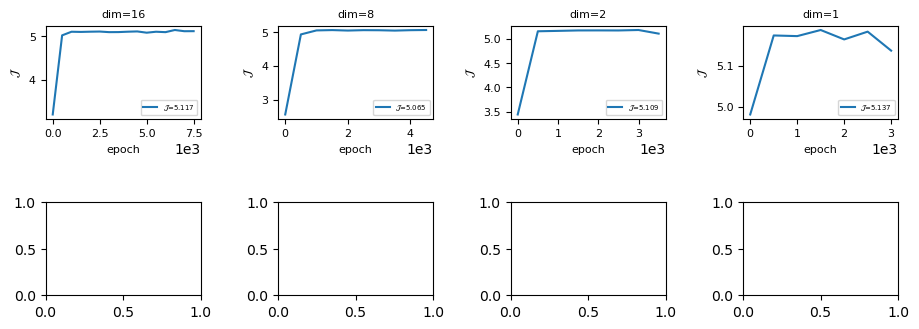

In [3]:
fig,ax1=plt.subplots(2,4, figsize= (11, 3.5))  
scale_number = [16, 8, 2, 1]
ei_all = []
all_ei_list = []

left, right = 0, 0 
for weights in range(1,5): 
    term1_list1 = pd.read_csv('./loc_result_stage2/stage2_kuramoto_macro/term1_scale%s.csv'%(weights),header=None)
    term1_list2 = pd.read_csv('./loc_result_stage2/stage2_kuramoto_macro/term2_scale%s.csv'%(weights),header=None)
    term_all = np.array(term1_list1) + np.array(term1_list2)
    smooth_data, ei = cal_data(term_all)
    all_ei_list.append(smooth_data)
    # ax1[left][right].plot(np.arange(term_all.shape[0])*1000, term_all, label=r'$\mathcal{J}$')
    ei_all.append(ei[0])
    ax1[left][right].plot((np.arange(smooth_data.shape[0])*500), smooth_data, label=r'$\mathcal{J}$=%s'%(round(cal_data(term_all)[1][0],3)))
    ax1[left][right].set_title('dim=%s'%(scale_number[weights-1]), fontsize=8)
    ax1[left][right].set_xlabel('epoch', fontsize=8)
    ax1[left][right].set_ylabel(r'$\mathcal{J}$', fontsize=8)
    # ax1[left][right].xaxis.set_major_formatter(ScalarFormatter(useMathText=True))
    ax1[left][right].ticklabel_format(axis='x', style='sci', scilimits=(0,0))
    # ax1[left][right].xaxis.set_ticks(x + bar_width, freq_list)
    ax1[left][right].tick_params(labelsize=8)    
    # if left ==0 and right ==0:
    # ax1[left][right].set_ylim(0,4)     
    ax1[left][right].legend(fontsize=5)    
    right += 1    
    if right %4 == 0:    
        left += 1   
        right = 0   
    plt.subplots_adjust(wspace=0.5, hspace=0.9) 

Saved figure to: /home/wangzhipeng/code/causal_network/causal_network/kumamoto/causal_network_mix_2_0.2_kuma_theta_inn_sin/loc_result_stage2/stage2_macro/ei_tail_mean_all_scales.png


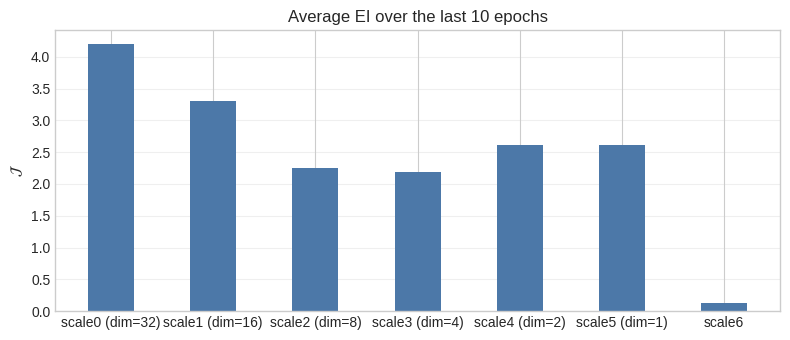

In [5]:
tail_mean_map = {
    scale_labels[scale_id]: float(np.mean(ei_series[scale_id][-10:]))
    for scale_id in available_scale_ids
}

plt.figure(figsize=(8, 3.5))
plt.bar(list(tail_mean_map.keys()), list(tail_mean_map.values()), width=0.45, color="#4C78A8")
plt.ylabel(r"$\mathcal{J}$")
plt.title("Average EI over the last 10 epochs")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()

ei_tail_save_path = result_dir / "ei_tail_mean_all_scales.png"
plt.savefig(ei_tail_save_path, dpi=200, bbox_inches="tight")
print(f"Saved figure to: {ei_tail_save_path}")
plt.show()


In [6]:
scale_labels

{0: 'scale0 (dim=32)',
 1: 'scale1 (dim=16)',
 2: 'scale2 (dim=8)',
 3: 'scale3 (dim=4)',
 4: 'scale4 (dim=2)',
 5: 'scale5 (dim=1)',
 6: 'scale6'}

Saved figure to: /home/wangzhipeng/code/causal_network/causal_network/kumamoto/causal_network_mix_2_0.2_kuma_theta_inn_sin/loc_result_stage2/stage2_macro/term1_term2_epoch_scale0.png


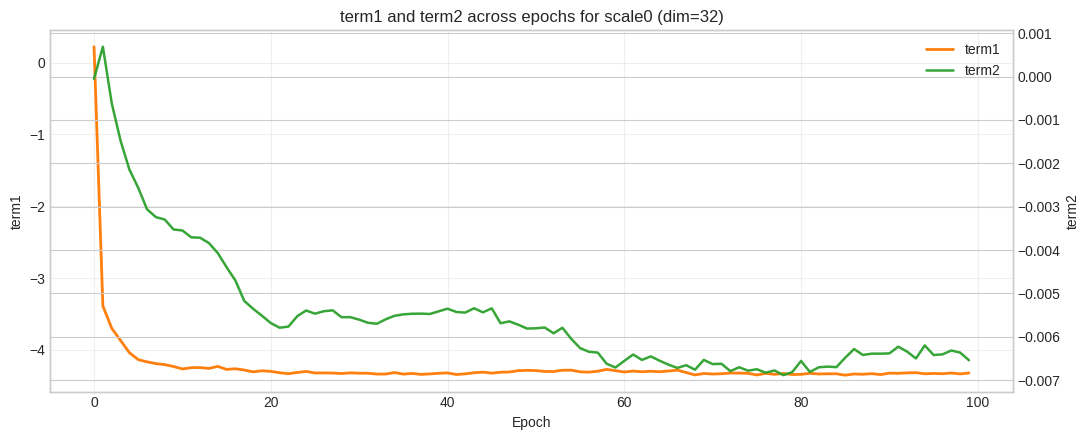

Saved figure to: /home/wangzhipeng/code/causal_network/causal_network/kumamoto/causal_network_mix_2_0.2_kuma_theta_inn_sin/loc_result_stage2/stage2_macro/term1_term2_epoch_scale1.png


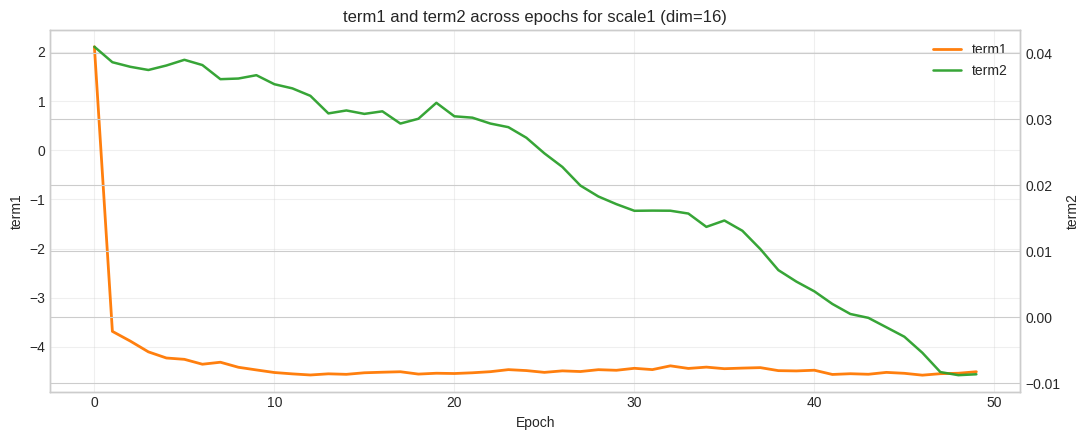

Saved figure to: /home/wangzhipeng/code/causal_network/causal_network/kumamoto/causal_network_mix_2_0.2_kuma_theta_inn_sin/loc_result_stage2/stage2_macro/term1_term2_epoch_scale2.png


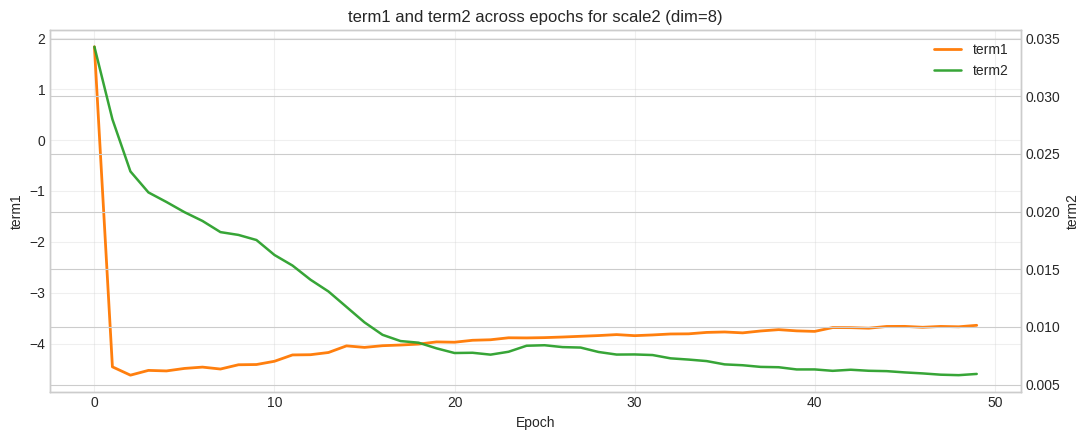

Saved figure to: /home/wangzhipeng/code/causal_network/causal_network/kumamoto/causal_network_mix_2_0.2_kuma_theta_inn_sin/loc_result_stage2/stage2_macro/term1_term2_epoch_scale3.png


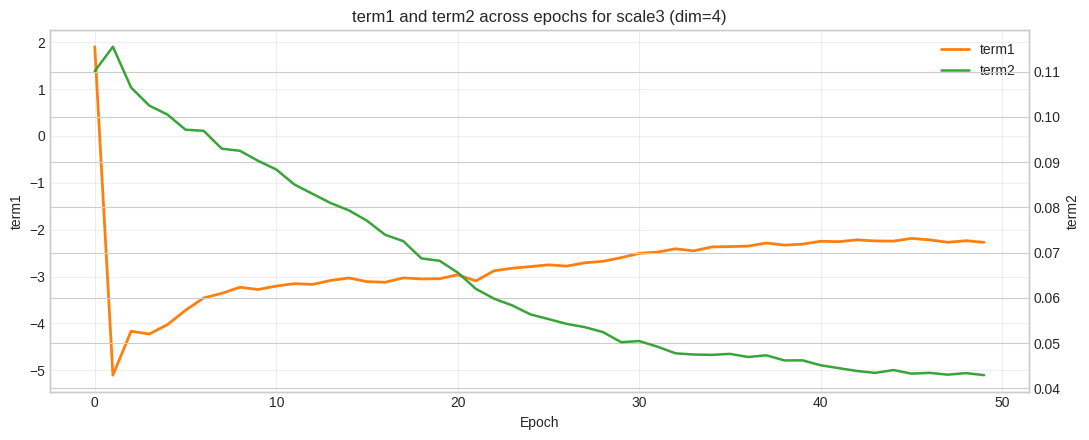

Saved figure to: /home/wangzhipeng/code/causal_network/causal_network/kumamoto/causal_network_mix_2_0.2_kuma_theta_inn_sin/loc_result_stage2/stage2_macro/term1_term2_epoch_scale4.png


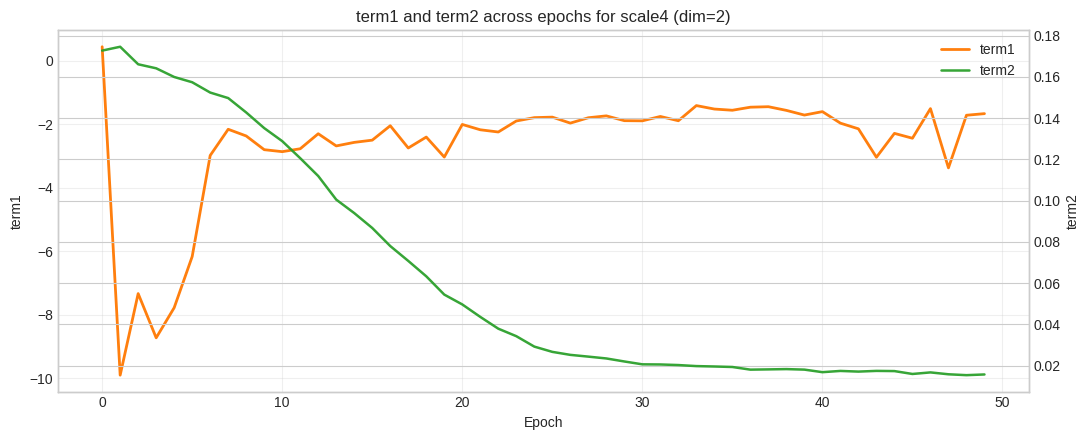

Saved figure to: /home/wangzhipeng/code/causal_network/causal_network/kumamoto/causal_network_mix_2_0.2_kuma_theta_inn_sin/loc_result_stage2/stage2_macro/term1_term2_epoch_scale5.png


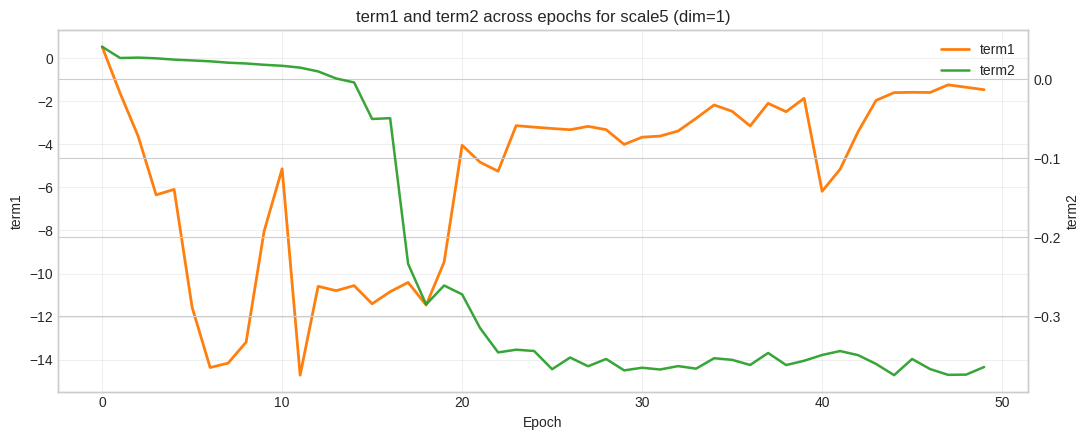

{0: PosixPath('/home/wangzhipeng/code/causal_network/causal_network/kumamoto/causal_network_mix_2_0.2_kuma_theta_inn_sin/loc_result_stage2/stage2_macro/term1_term2_epoch_scale0.png'),
 1: PosixPath('/home/wangzhipeng/code/causal_network/causal_network/kumamoto/causal_network_mix_2_0.2_kuma_theta_inn_sin/loc_result_stage2/stage2_macro/term1_term2_epoch_scale1.png'),
 2: PosixPath('/home/wangzhipeng/code/causal_network/causal_network/kumamoto/causal_network_mix_2_0.2_kuma_theta_inn_sin/loc_result_stage2/stage2_macro/term1_term2_epoch_scale2.png'),
 3: PosixPath('/home/wangzhipeng/code/causal_network/causal_network/kumamoto/causal_network_mix_2_0.2_kuma_theta_inn_sin/loc_result_stage2/stage2_macro/term1_term2_epoch_scale3.png'),
 4: PosixPath('/home/wangzhipeng/code/causal_network/causal_network/kumamoto/causal_network_mix_2_0.2_kuma_theta_inn_sin/loc_result_stage2/stage2_macro/term1_term2_epoch_scale4.png'),
 5: PosixPath('/home/wangzhipeng/code/causal_network/causal_network/kumamoto/cau

In [4]:
single_scale_paths = {}
for scale_id in available_scale_ids:
    _, _, save_path = plot_term_pair_single_scale(
        scale_id=scale_id,
        term1_values=term1_series[scale_id],
        term2_values=term2_series[scale_id],
        scale_label=scale_labels[scale_id],
        result_dir=result_dir,
        show=True,
    )
    single_scale_paths[scale_id] = save_path

single_scale_paths


Saved figure to: /home/wangzhipeng/code/causal_network/causal_network/kumamoto/causal_network_mix_2_0.2_kuma_theta_inn_sin/loc_result_stage2/stage2_macro/term1_term2_epoch_all_scales.png


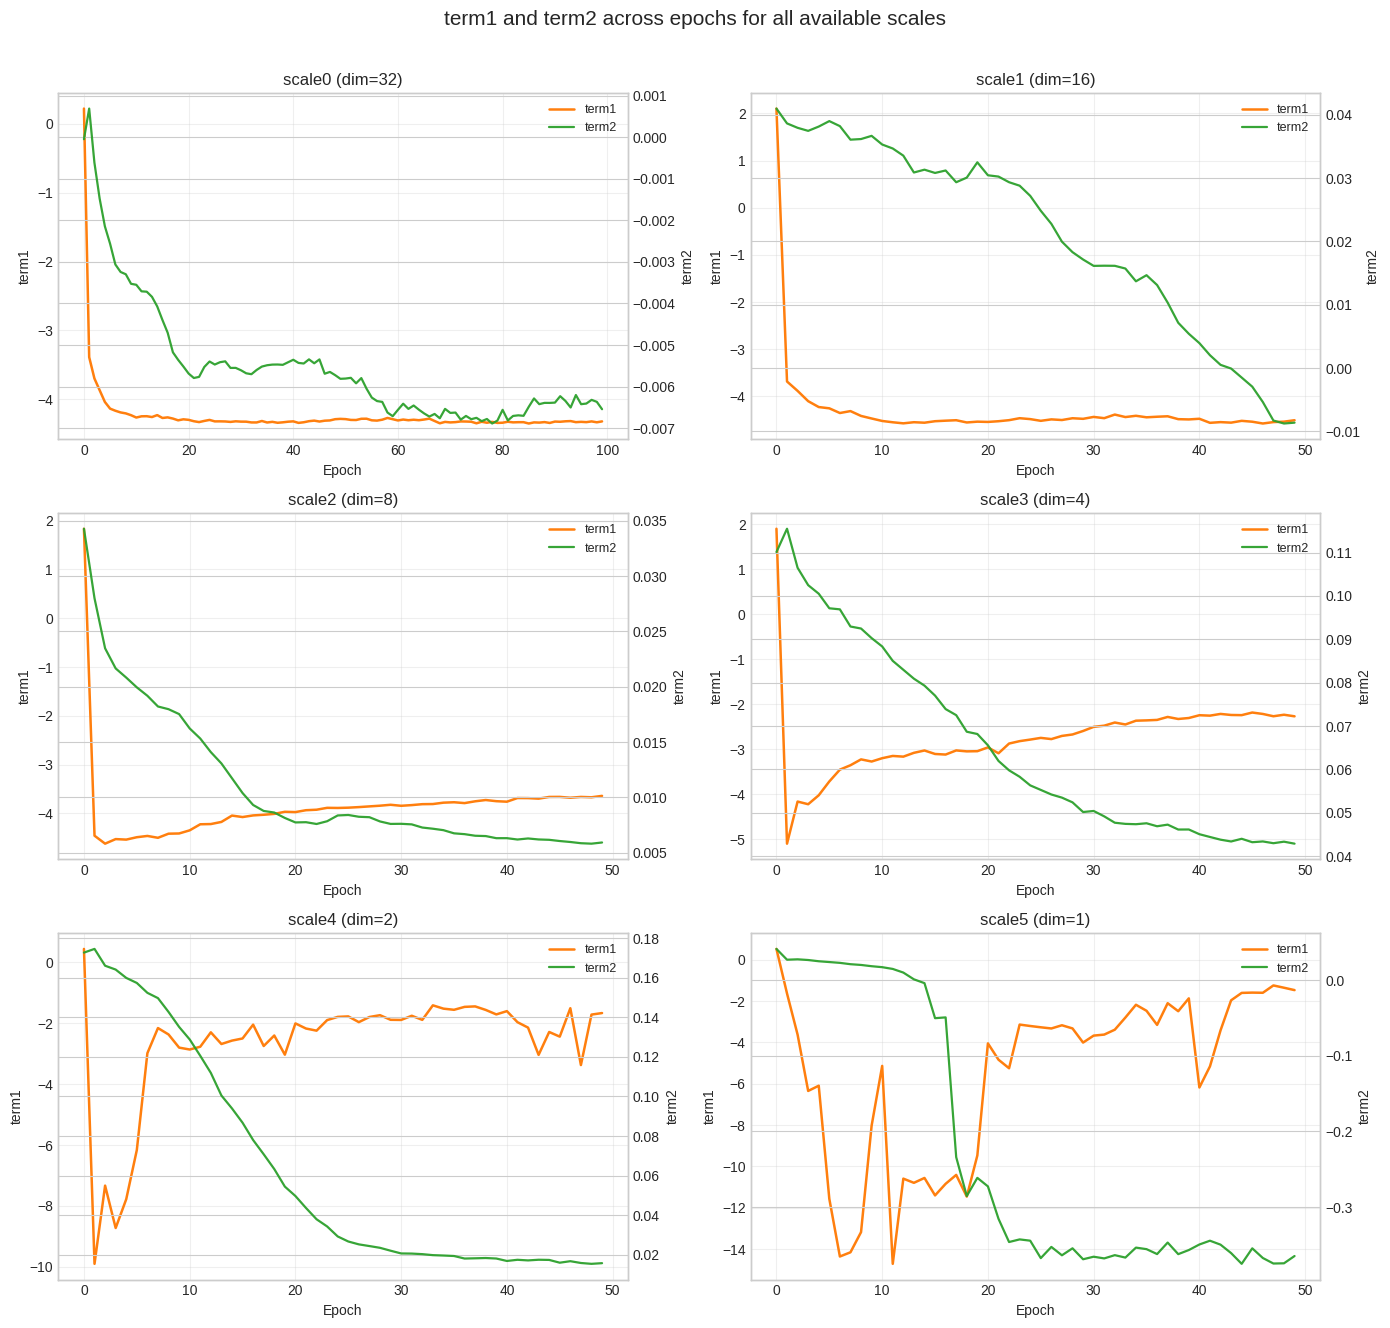

PosixPath('/home/wangzhipeng/code/causal_network/causal_network/kumamoto/causal_network_mix_2_0.2_kuma_theta_inn_sin/loc_result_stage2/stage2_macro/term1_term2_epoch_all_scales.png')

In [5]:
_, term_grid_save_path = plot_term_pairs_grid(
    term1_series=term1_series,
    term2_series=term2_series,
    scale_labels=scale_labels,
    cols=2,
    result_dir=result_dir,
    show=True,
)

term_grid_save_path
